# Case 4: Churn Detective - Telecom Retention Brief

This notebook turns the telecom churn dataset into a CMO-ready retention brief. The goal is not only to predict churn, but to explain who is at risk, why they are at risk, what offer to make, and how to measure the campaign in the first 60 days.

## Executive Summary

- Base churn rate: **36.16%**.
- Selected model for risk ranking: **Random Forest**.
- Held-out ROC-AUC: **0.7242**; PR-AUC: **0.5744**.
- Top-20% targeting captures **170 churners out of 280 targeted customers**.
- Top-20% precision: **60.71%**, or **1.68x lift** over random targeting.
- Main risk themes: short tenure, month-to-month contracts, repeated support calls, payment friction, electronic checks, and high monthly charges.
- Recommended plays: **Payment Friction Fix**, **Service Rescue**, and **Price-Lock / Contract Upgrade**.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / 'case4_telecom_churn.csv'
TABLES = ROOT / 'reports' / 'tables'
FIGURES = ROOT / 'reports' / 'figures'

df = pd.read_csv(DATA_PATH)
df.shape

(7000, 21)

## 1. Data Audit

The dataset has 7,000 customers, 20 input features, and one binary target: `churned`.

In [2]:
pd.read_csv(TABLES / 'data_audit_summary.csv')

,metric,value
0,rows,7000.0000
1,columns,21.0000
2,duplicate_customer_ids,0.0000
3,churn_rate,0.3616
4,churned_customers,2531.0000
5,retained_customers,4469.0000
6,tenure_mean_months,22.6400
7,tenure_median_months,16.0000
8,monthly_charges_mean,69.8400
9,monthly_charges_min,20.0100


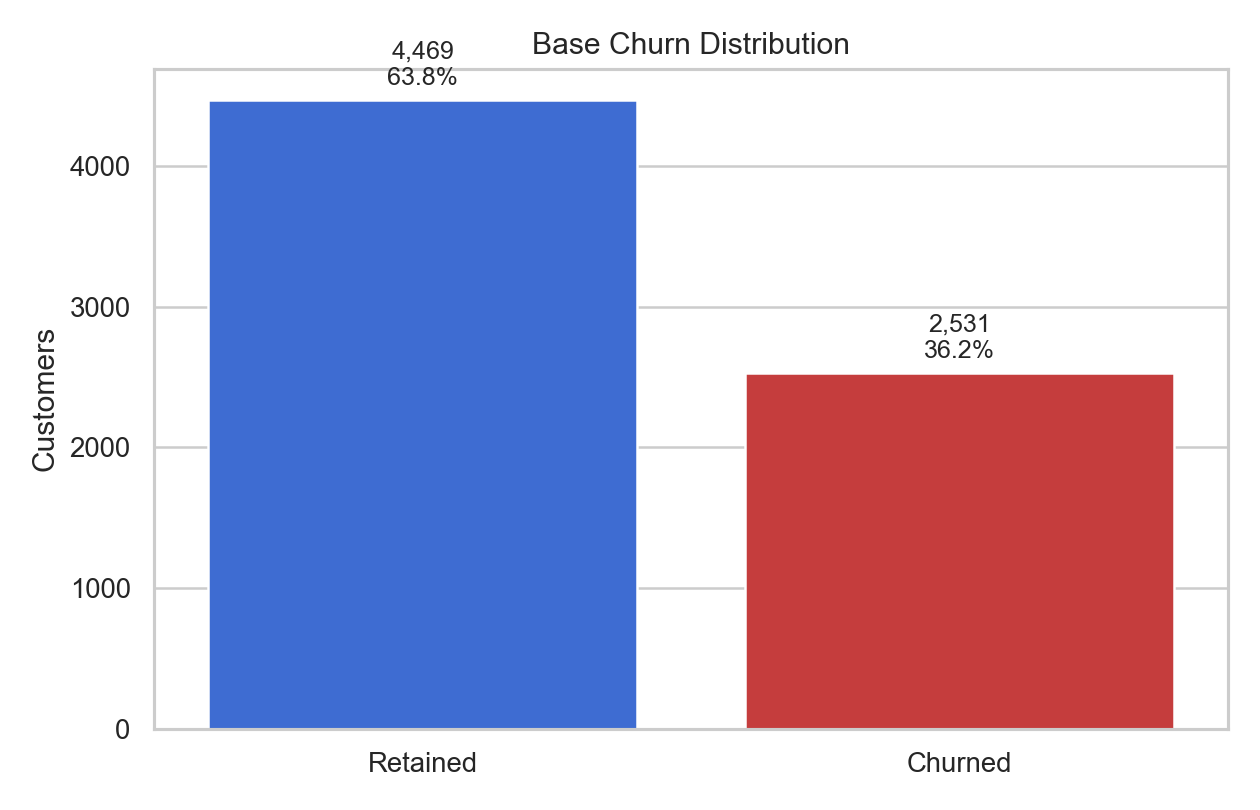

In [3]:
Image(filename=str(FIGURES / 'base_churn_distribution.png'))

## 2. Churn Driver Evidence

The CMO asked for evidence, not only feature-importance bars. The tables and charts below show churn-rate gaps across business-readable groups.

In [4]:
pd.read_csv(TABLES / 'churn_driver_summary.csv')

,driver,highest_risk_group,highest_churn_rate,lowest_risk_group,lowest_churn_rate,risk_gap_pct_points
0,tenure_bucket,0-6,0.4940,49-72,0.2255,26.85
1,contract_type,Month-to-month,0.4675,Two year,0.2262,24.13
2,support_calls_bucket,6+,0.5295,1-2,0.3298,19.97
3,late_payments_bucket,2+,0.5238,1,0.3441,17.97
4,payment_method,Electronic check,0.4432,Credit card (auto),0.3108,13.24
5,monthly_charge_bucket,Q4 highest,0.4041,Q1 lowest,0.3337,7.04
6,tech_support,No,0.3851,Yes,0.3296,5.55


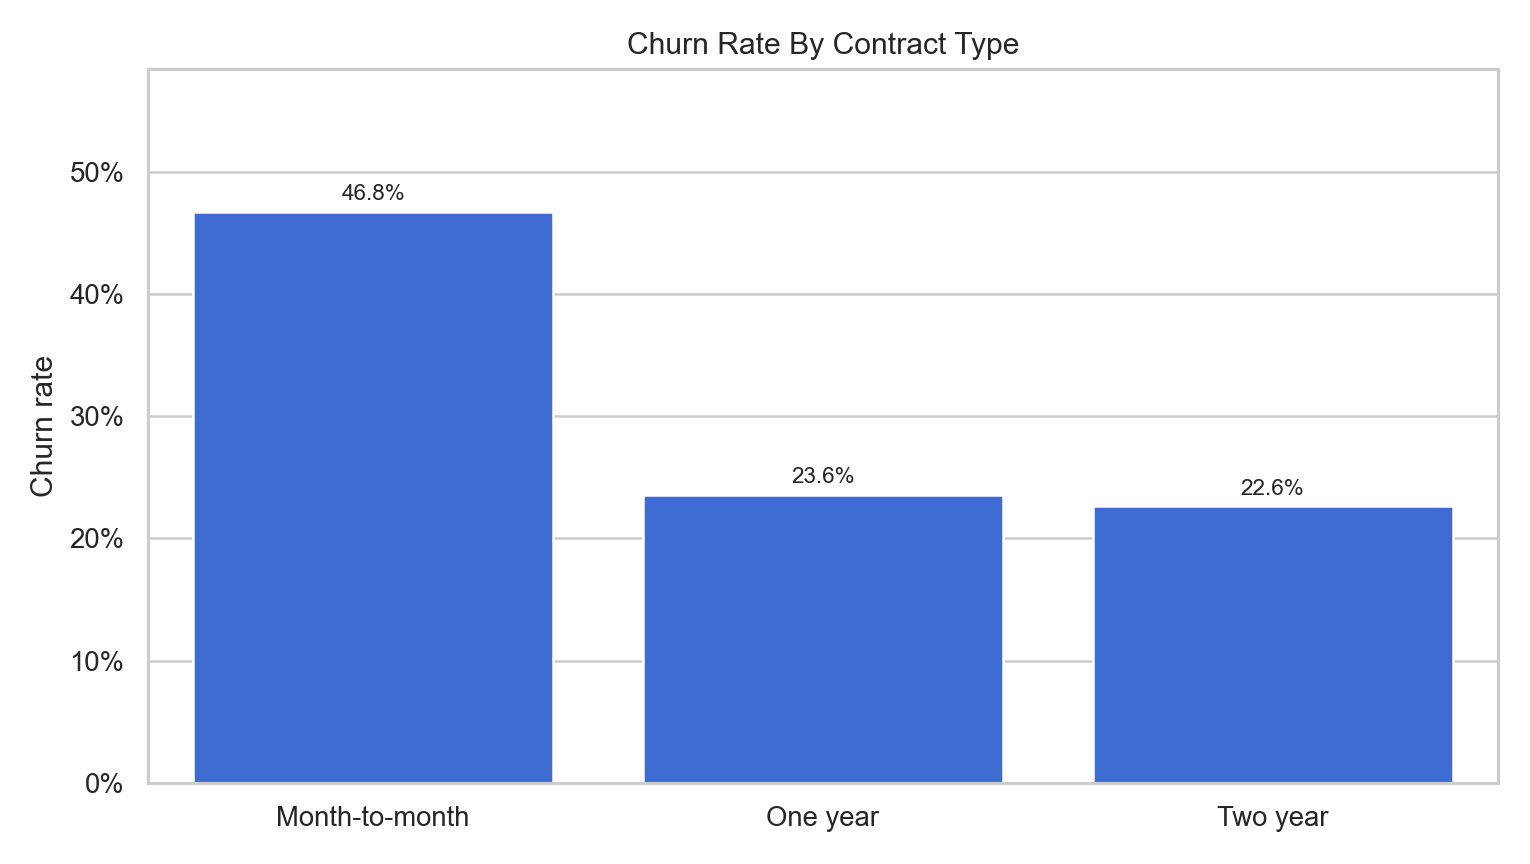

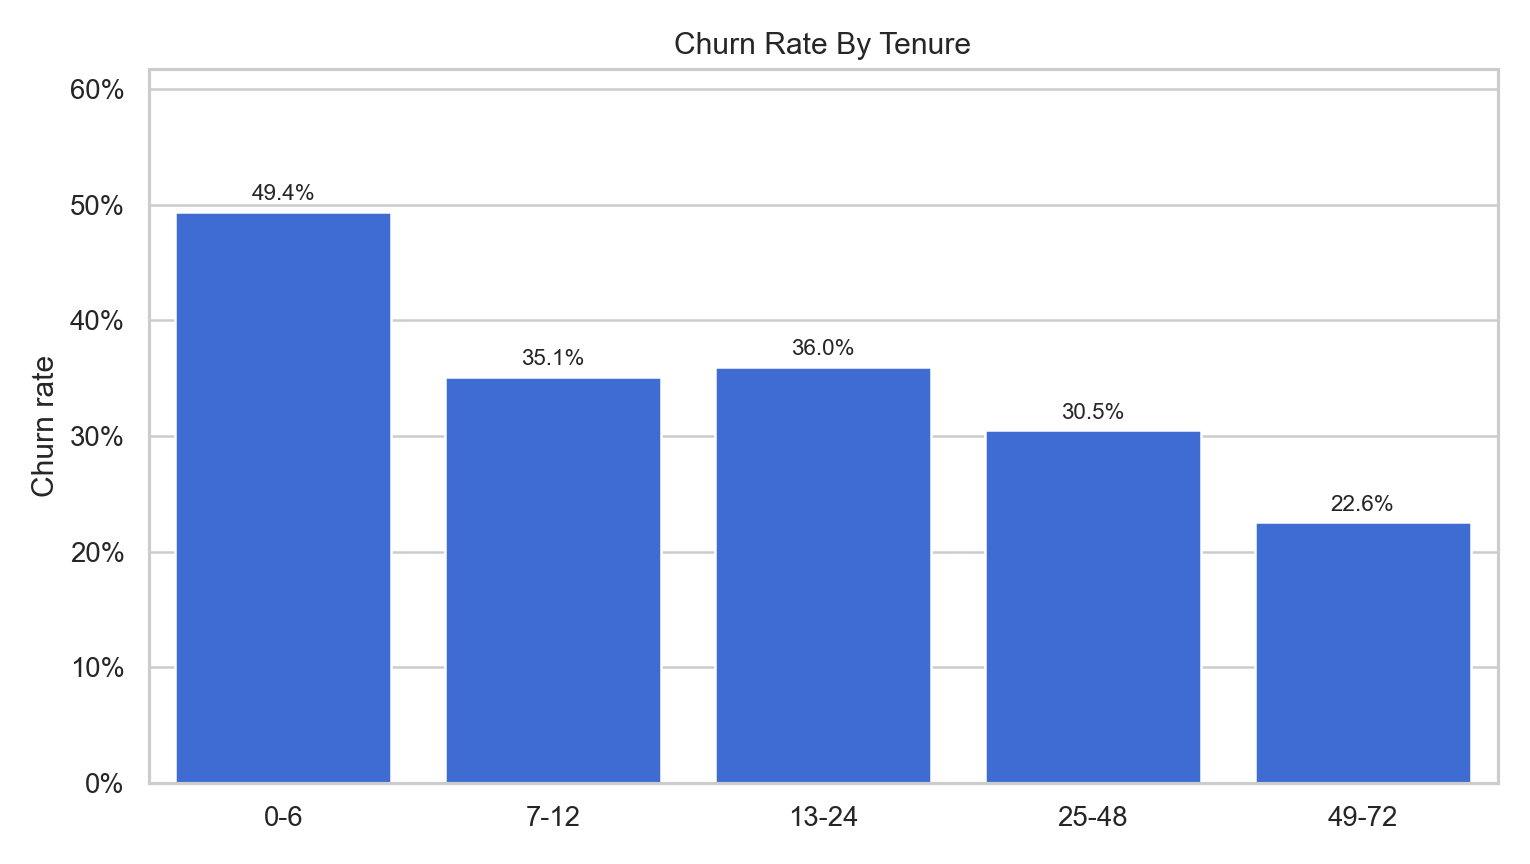

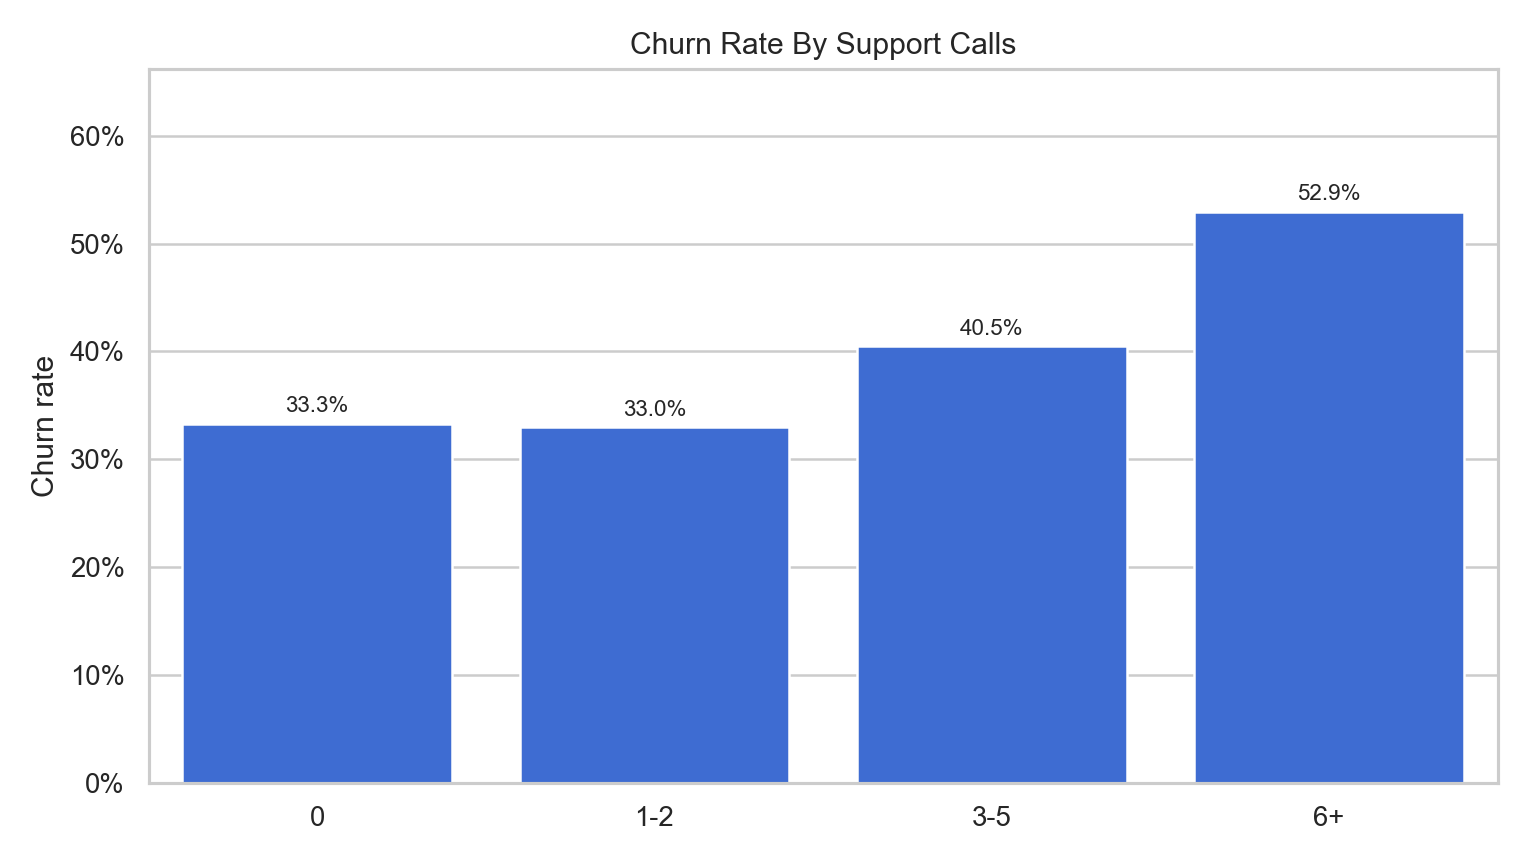

In [5]:
display(Image(filename=str(FIGURES / 'churn_by_contract_type.png')))
display(Image(filename=str(FIGURES / 'churn_by_tenure_bucket.png')))
display(Image(filename=str(FIGURES / 'churn_by_support_calls.png')))

Key interpretation:

- Month-to-month customers churn far more than one-year and two-year customers.
- Early-tenure customers are fragile and need onboarding attention.
- Customers with repeated support calls are service-frustrated and should not receive only a generic discount.

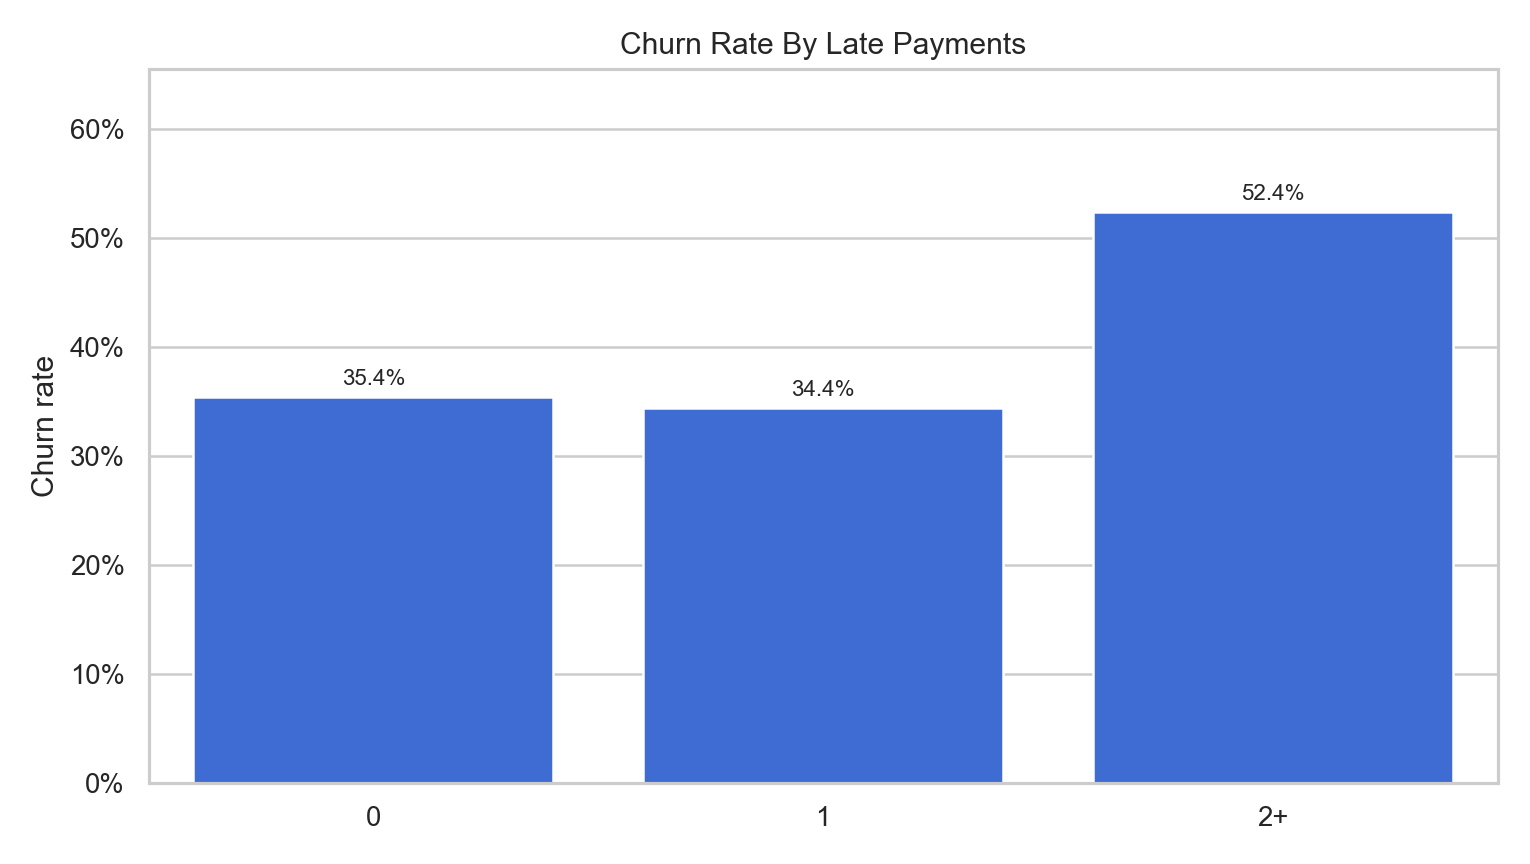

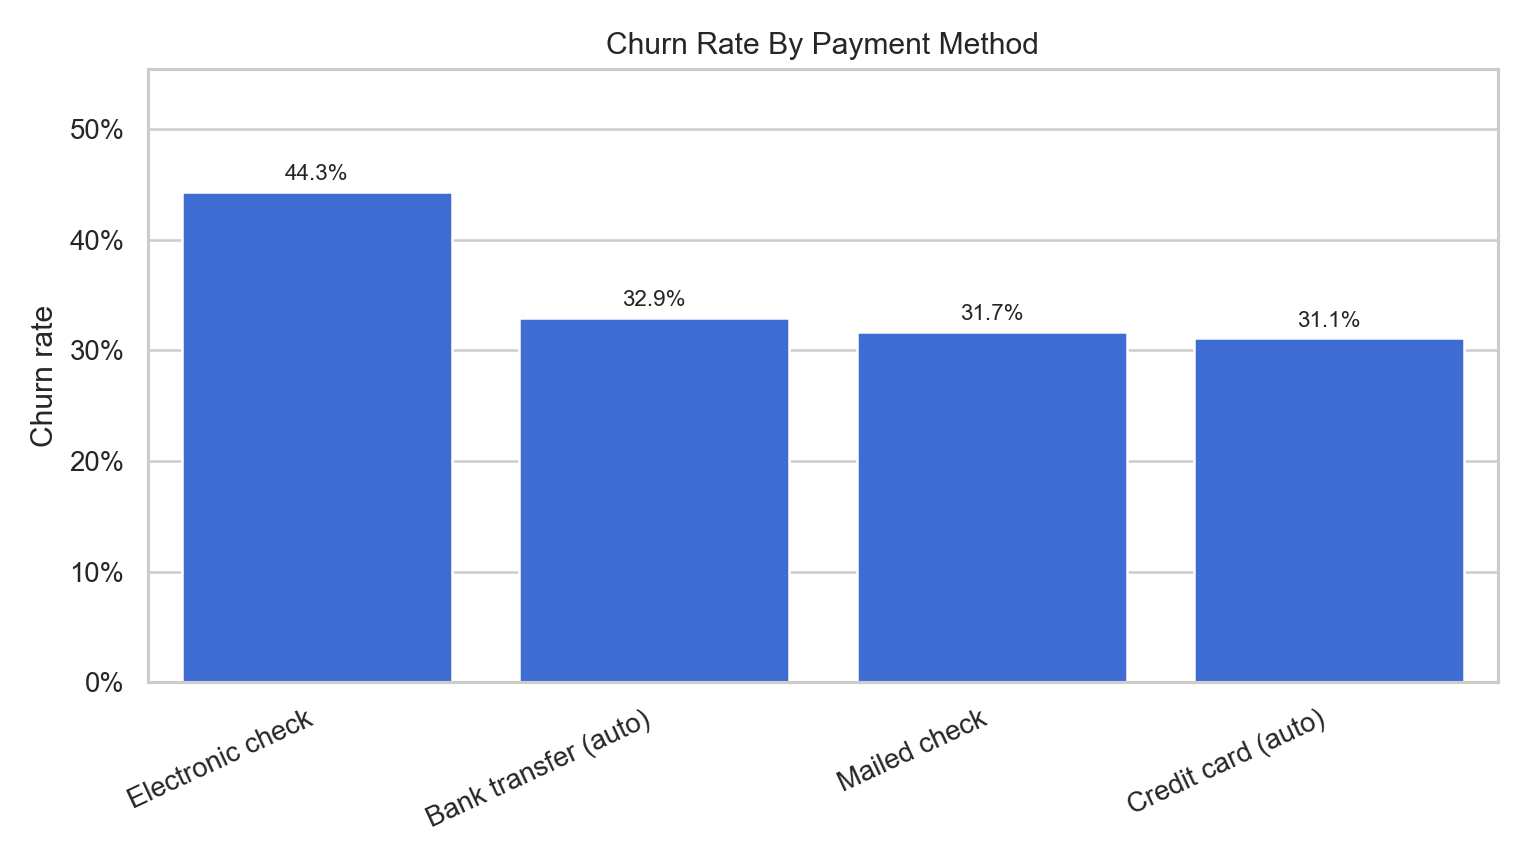

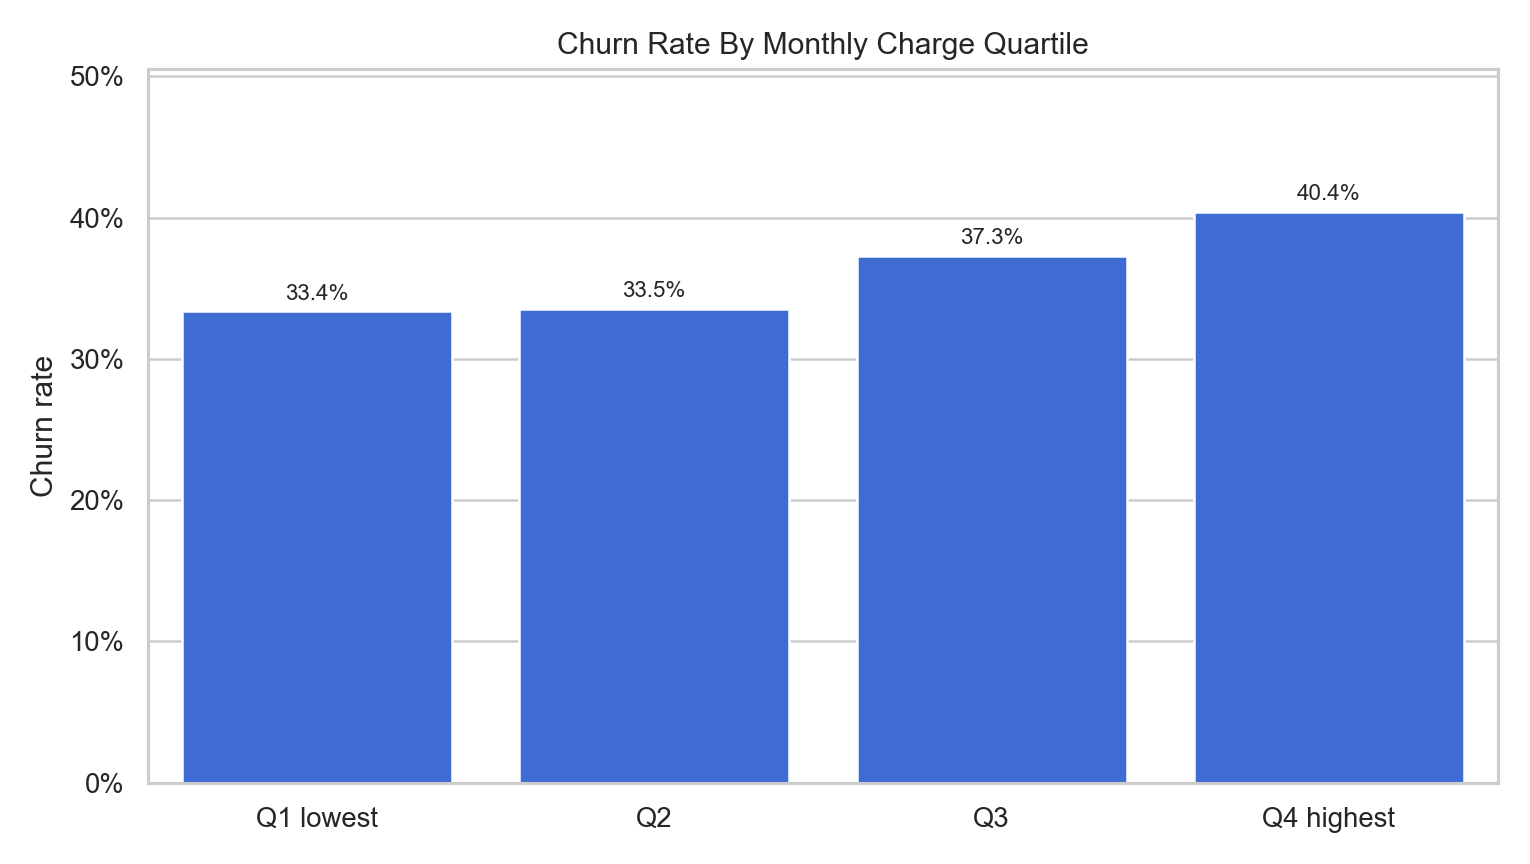

In [6]:
display(Image(filename=str(FIGURES / 'churn_by_late_payments.png')))
display(Image(filename=str(FIGURES / 'churn_by_payment_method.png')))
display(Image(filename=str(FIGURES / 'churn_by_monthly_charge_bucket.png')))

Payment friction and price pressure matter, but they should be targeted carefully. The strongest price play is not for every expensive customer; it is for high-risk customers with high monthly charges and flexible contracts.

## 3. Modeling

A Logistic Regression baseline gives interpretable directionality. A Random Forest slightly improves ranking metrics, so it is selected for churn-risk ranking.

In [7]:
pd.read_csv(TABLES / 'model_candidate_comparison.csv')

,model,test_rows,base_churn_rate_test,roc_auc,pr_auc,accuracy,precision,recall,f1
0,random_forest,1400,0.3614,0.7242,0.5744,0.6500,0.5125,0.6482,0.5724
1,logistic_regression,1400,0.3614,0.7191,0.5677,0.6629,0.5256,0.6897,0.5966


In [8]:
pd.read_csv(TABLES / 'baseline_top_coefficients.csv').head(12)

,feature,coefficient,abs_coefficient
0,contract_type_Month-to-month,0.780612,0.780612
1,contract_type_Two year,-0.467012,0.467012
2,payment_method_Electronic check,0.403837,0.403837
3,contract_type_One year,-0.403788,0.403788
4,tenure_months,-0.335281,0.335281
5,support_calls_3mo,0.313746,0.313746
6,internet_service_DSL,-0.297605,0.297605
7,internet_service_Fiber optic,0.237533,0.237533
8,payment_method_Credit card (auto),-0.224447,0.224447
9,tech_support_Yes,-0.210087,0.210087


Model choice:

- **Random Forest** is used for ranking customers because it has the best ROC-AUC and PR-AUC.
- **Logistic Regression** remains useful for interpretation because coefficients show directionality.

## 4. Campaign Threshold

The CMO cannot target everyone. Instead of using a default 0.5 classification threshold, customers are ranked by churn probability and evaluated at campaign-size thresholds.

In [9]:
pd.read_csv(TABLES / 'campaign_threshold_evaluation.csv')

,target_top_pct,targeted_customers,churners_found,precision_at_threshold,recall_at_threshold,lift_vs_random,avg_monthly_charge_targeted
0,10,140,86,0.6143,0.1700,1.70,79.43
1,20,280,170,0.6071,0.3360,1.68,74.99
2,30,420,243,0.5786,0.4802,1.60,71.38


Recommendation: start with the **top 20% highest-risk customers**. This gives a manageable outreach pool and captures one-third of churners with 1.68x lift over random targeting.

## 5. High-Risk Segments

Segments are designed for campaign action. Since customer risks can overlap, both primary segment and membership views are saved.

In [10]:
pd.read_csv(TABLES / 'high_risk_segment_summary.csv')

,primary_segment,customers,churners,churn_rate,avg_churn_probability,avg_monthly_charge,avg_tenure_months,avg_support_calls,avg_late_payments,share_of_top20_pool
0,Service-frustrated,117,71,0.6068,0.6964,72.9948,10.5983,5.0513,0.3675,0.4179
1,Payment-friction,87,58,0.6667,0.6893,72.5317,9.7011,0.9655,0.4368,0.3107
2,General high-risk,27,16,0.5926,0.6501,55.1719,15.8519,1.1481,0.3333,0.0964
3,Price-sensitive,32,14,0.4375,0.6731,108.6650,8.6250,1.1250,0.4062,0.1143
4,New-customer onboarding,17,11,0.6471,0.6718,69.3824,2.3529,0.9412,0.2941,0.0607


In [11]:
pd.read_csv(TABLES / 'high_risk_segment_membership_summary.csv')

,segment,customers,churners,churn_rate,share_of_top20_pool,avg_churn_probability
0,Payment-friction,141,95,0.6738,0.5036,0.6974
1,New-customer onboarding,127,85,0.6693,0.4536,0.7056
2,Service-frustrated,117,71,0.6068,0.4179,0.6964
3,Price-sensitive,90,56,0.6222,0.3214,0.6935


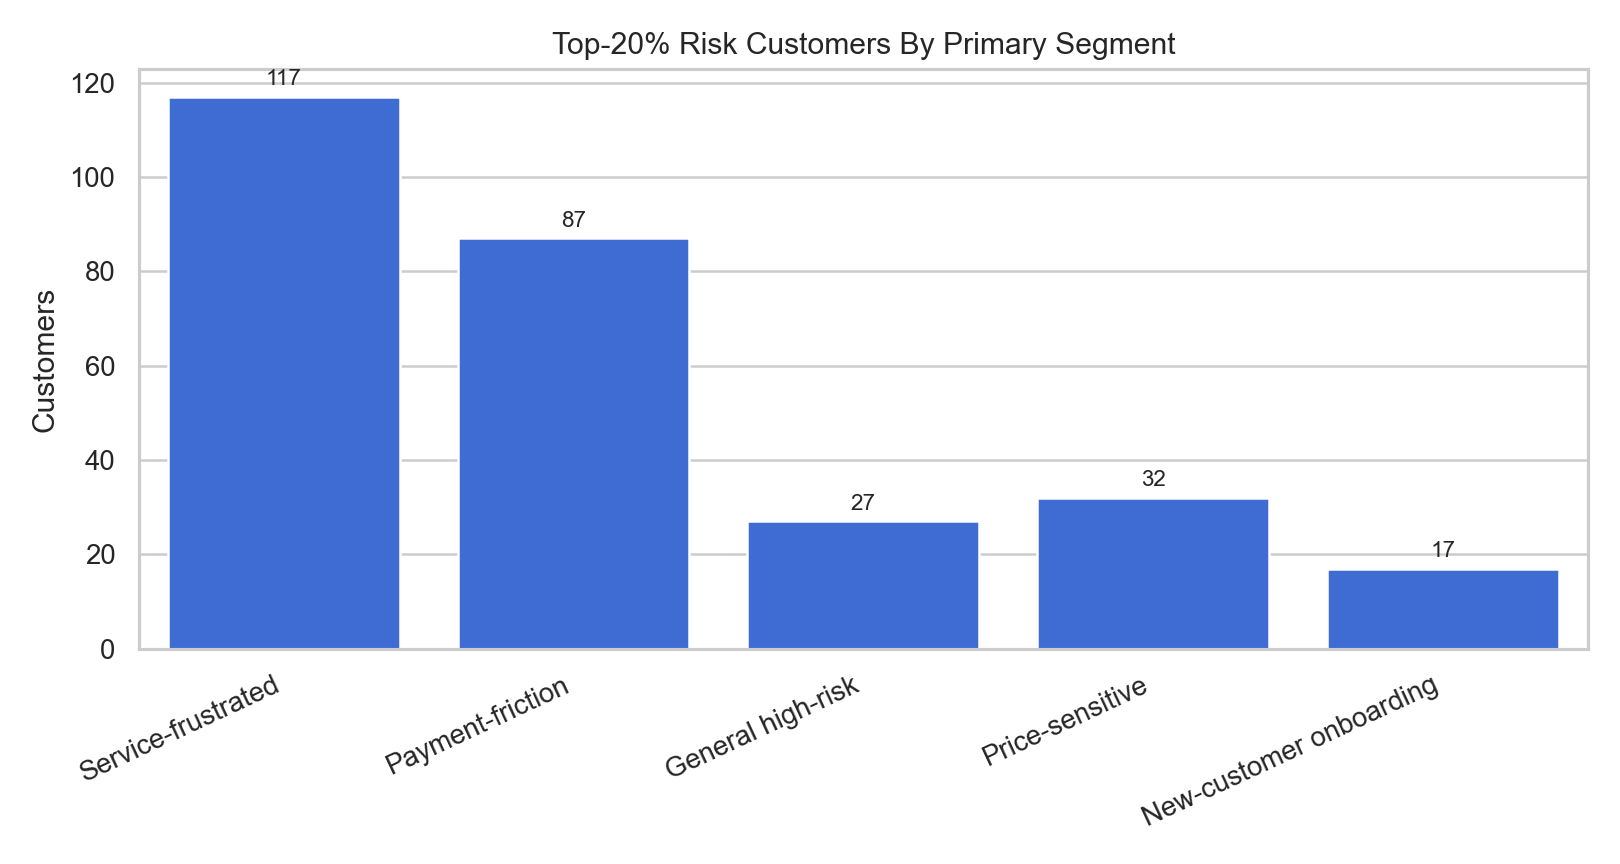

In [12]:
Image(filename=str(FIGURES / 'high_risk_primary_segments.png'))

## 6. Retention Plays

1. **Payment Friction Fix**: autopay incentive, billing reminders, and late-fee waiver after autopay enrollment.
2. **Service Rescue**: priority callback, issue owner, escalation SLA, and free tech-support trial.
3. **Price-Lock / Contract Upgrade**: price lock, annual-contract discount, or plan-rightsizing review.

The rough top-20% impact estimate is 17.0-25.5 saved customers and $7,648.98-$11,473.47 gross six-month revenue saved before offer costs, assuming 10-15% of identified churners are saved.

## 7. Limitations And Risks

- Observational data does not prove causality.
- The model predicts churn risk, not offer responsiveness.
- Discounts can waste margin on customers who would stay anyway.
- High-risk segments overlap and need campaign priority rules.
- Customer behavior may change next quarter.
- Features may proxy for sensitive or regulated attributes, so campaign policy should be reviewed.

## 8. 60-Day Measurement Plan

1. Rank eligible customers by churn probability.
2. Randomly split top-risk customers into treatment and holdout groups within each segment.
3. Apply segment-specific offers to treatment only.
4. Track 60-day churn, offer acceptance, support calls, late payments, and retained revenue.
5. Compare treatment versus holdout by segment.
6. Scale only plays with positive net value after offer costs.

Primary success metric: **60-day churn reduction in treatment group versus holdout group**.